In [1]:
import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import dill
import jax
import jax.numpy as jnp
import json
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd

from flax import nnx
from torch.utils.data import DataLoader
from typing import Any, NamedTuple
from typing_extensions import Protocol, runtime_checkable

from src.dataset import get_iter
from src.datasets.sum import Addition
from src.decoding import make_autoregressive
from src.utils import parse_dict

## Helpers

In [3]:
class StepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    eos_token: int
    rng: chex.PRNGKey
    sequence: chex.Array
    is_prompt: chex.Array
    eos: chex.Array
    logits: chex.Array
    step_i: int = 0
    deterministic: int = 0


def predict_step(
    step_state: StepState,
):
    step_i = step_state.step_i
    rng, rng_step = jax.random.split(step_state.rng, 2)

    # Autoregressively decode
    module = nnx.merge(step_state.graphdef, step_state.rest, step_state.cache)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)
    logits = module({"sequence": step_state.sequence[:, [step_i]],},)
    cache = nnx.state(module, nnx.Cache)

    logits = logits[:, 0]

    output_tokens = jax.lax.cond(
        step_state.deterministic,
        lambda rng_step, logits: jnp.argmax(logits, axis=-1),
        jax.random.categorical,
        rng_step,
        logits,
    )

    # Check for prompt boundary
    is_prompt = step_state.is_prompt[:, step_i]

    output_tokens = jnp.where(
        is_prompt,
        step_state.sequence[:, step_i + 1],
        output_tokens,
    )

    # Check if the first EOS has been generated
    eos = jnp.logical_or(
        output_tokens == step_state.eos_token,
        step_state.eos[:, step_i],
    )

    # Update the entries on the i'th step
    sequence = step_state.sequence.at[:, step_i + 1].set(output_tokens)
    eos = step_state.eos.at[:, step_i + 1].set(eos)
    all_logits = step_state.logits.at[:, step_i + 1].set(logits)

    step_state = StepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        eos_token=step_state.eos_token,
        rng=rng,
        sequence=sequence,
        is_prompt=step_state.is_prompt,
        eos=eos,
        step_i=step_i + 1,
        deterministic=step_state.deterministic,
        logits=all_logits,
    )

    return step_state

@nnx.jit(static_argnames=["out_dim"])
def rollout(
    graphdef: Any,
    cache: Any,
    rest: Any,
    rng: chex.PRNGKey,
    batch: Any,
    out_dim: int,
    eos_token: int,
    deterministic: int = 0,
):
    questions = batch["sequence"]
    mask = batch["mask"]
    num_questions, max_step = questions.shape

    step_state = StepState(
        graphdef=graphdef,
        rest=rest,
        cache=cache,
        eos_token=eos_token,
        rng=rng,
        sequence=questions,
        is_prompt=1 - mask,
        eos=jnp.zeros((num_questions, max_step)),
        logits=jnp.zeros((num_questions, max_step, out_dim)),
        deterministic=deterministic,
    )

    step_state = jax.lax.while_loop(
        lambda state: state.step_i < max_step - 1,
        predict_step,
        step_state,
    )

    return {
        "response": step_state.sequence,
        "eos": step_state.eos,
        "is_prompt": step_state.is_prompt,
        "logits": step_state.logits,
    }


In [4]:
Dtype = Any
Shape = tuple[int, ...]
EOS_TOKEN = 4

@runtime_checkable
class HasCache(Protocol):
    def init_cache(self, input_shape: Shape, dtype: Dtype = jnp.float32): ...

def evaluate(
    learner_path,
    batch,
    out_dim,
    batch_size,
    eval_seed,
    num_evals,
    max_decode_len,
    dtype,
    checkpoint_i=-1,
    stochastic=False,
):
    config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

    # Load model
    last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[checkpoint_i]
    train_state = dill.load(
        open(os.path.join(learner_path, "models", last_step), "rb")
    )

    # print(train_state.params)
    model = nnx.merge(
        train_state.graphdef,
        train_state.params,
        train_state.rest,
    )

    rng = jax.random.PRNGKey(eval_seed)
    rng, rollout_rng = jax.random.split(rng)

    # Sample next batch and evaluate
    _, init_cache = make_autoregressive(
        model,
        max_decode_len=max_decode_len,
        batch_size=batch_size * num_evals,
        embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
        dtype=dtype,
        eval_mode=True,
    )
    cache = init_cache()
    graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

    rollout_res = rollout(
        graphdef,
        cache,
        rest,
        rollout_rng,
        {
            "sequence": np.repeat(batch["sequence"], num_evals, axis=0),
            "mask": np.repeat(batch["mask"], num_evals, axis=0),
            "target": np.repeat(batch["target"], num_evals, axis=0),
        },
        out_dim=out_dim,
        eos_token=EOS_TOKEN,
        deterministic=1 - int(stochastic),
    )

    return rollout_res


def compute_success_rate(batch, batch_size, num_evals):
    response_lengths = np.zeros(batch["sequence"].shape[0])
    successes = np.zeros(batch["sequence"].shape[0])
    has_eos = np.zeros(batch["sequence"].shape[0])

    # Get whether or not target is in the response---neglects everything after first <EOS>
    for sample_i, (response, target, mask) in enumerate(
        zip(batch["sequence"], batch["target"], batch["pred_mask"])
    ):
        target = "".join(np.array(target[target != EOS_TOKEN]).astype(str)) + "4"

        # XXX: Currently look at the first <EOS>
        if EOS_TOKEN in response:
            response = "".join(np.array(
                response[:np.where(response == EOS_TOKEN)[0][0] + 1]
            ).astype(str))
            has_eos[sample_i] = 1.0
        else:
            response = "".join(np.array(response).astype(str))
            has_eos[sample_i] = 0.0

        response_length = np.sum(mask)

        success = float(target in response)

        response_lengths[sample_i] = response_length
        successes[sample_i] = success

    return {
        "successes": successes.reshape((batch_size, num_evals)),
        "response_lengths": response_lengths.reshape((batch_size, num_evals)),
        "has_eos": has_eos.reshape((batch_size, num_evals)),
    }


## Evaluate

In [5]:
base_path = "/home/bryanpu1/projects/iclr_2026/icl_architecture/scaling_jax/results"

algo_name = "addition-debug"
run_name = "ppo-test-09-09-25_17_17_15-e2d71f79-8e0b-471f-bdc6-7846092878df"
# run_name = "reinforce-test-09-09-25_09_33_02-482c0077-58e5-4079-be6b-f5e1864622e5"

learner_path = os.path.join(base_path, algo_name, run_name)

In [15]:
all_res = dict(
    results=dict(),
    metrics=dict(),
)

eval_seed = 42
num_evals = 30

config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))
half_precision = config_dict["half_precision"]
dtype = jnp.bfloat16 if half_precision else jnp.float32

# Get dataset
config_dict["dataset_kwargs"]["max_int"] = 32
dataset_kwargs = parse_dict(config_dict["dataset_kwargs"])
max_decode_len = dataset_kwargs.context_len * 2

print(f"Max decode len: {max_decode_len}")
max_num_bits = int(np.ceil(np.log2(dataset_kwargs.max_int)))
for num_bits in range(1, max_num_bits + 1):
    curr_int = 2 ** num_bits
    batch_size = min(curr_int * curr_int, 100)
    dataset = Addition(
        context_len=max_decode_len,
        max_int=curr_int,
        train=True,
        seed=eval_seed,
        sequence_type="question_only",
        train_val_ratio=1.0,
        right_to_left=getattr(dataset_kwargs, "right_to_left", False),
        shuffle=False,
        exact=True,
    )

    print(f"Max int: {curr_int}")

    out_dim = int(dataset.output_space.n)
    data_loader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=0,
    )
    data_iter = get_iter(data_loader, None, dtype)
    batch = next(data_iter)

    checkpoint_i = 0
    while True:
        try:
            all_res["results"].setdefault(checkpoint_i, dict())
            all_res["metrics"].setdefault(checkpoint_i, dict())

            all_res["results"][checkpoint_i][num_bits] = evaluate(
                learner_path=learner_path,
                batch=batch,
                out_dim=out_dim,
                batch_size=batch_size,
                eval_seed=eval_seed,
                num_evals=num_evals,
                max_decode_len=max_decode_len,
                dtype=dtype,
                checkpoint_i=checkpoint_i,
                stochastic=True,
            )
            all_res["metrics"][checkpoint_i][num_bits] = compute_success_rate({
                "sequence": all_res["results"][checkpoint_i][num_bits]["response"],
                "target": np.repeat(
                    batch["target"],
                    num_evals,
                    axis=0,
                ),
                "pred_mask": 1 - np.logical_or(
                    all_res["results"][checkpoint_i][num_bits]["eos"],
                    all_res["results"][checkpoint_i][num_bits]["is_prompt"],
                ),
            }, batch_size, num_evals)
                
            checkpoint_i += 1
        except Exception as e:
            print(e)
            break

Max decode len: 32
Max int: 2
list index out of range
Max int: 4
list index out of range
Max int: 8
list index out of range
Max int: 16
list index out of range
Max int: 32
list index out of range


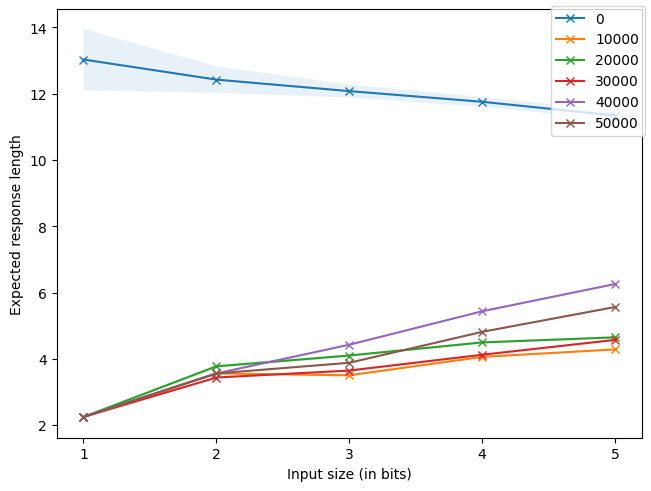

In [24]:
fig, ax = plt.subplots(1, 1, layout="constrained")

checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
prompt_lengths = np.argmax(batch["sequence"], axis=-1) // 2 - 1
for checkpoint_i, curr_metric in all_res["metrics"].items():
    input_length_range = sorted(curr_metric.keys())
    expected_response_lengths = []
    for num_bits in input_length_range:
        expected_response_lengths.append((
            np.mean(curr_metric[num_bits]["response_lengths"]),
            np.std(curr_metric[num_bits]["response_lengths"]) / np.sqrt(
                curr_metric[num_bits]["response_lengths"].shape[0]
                * curr_metric[num_bits]["response_lengths"].shape[1]
            ),
        ))

    expected_response_lengths = np.array(expected_response_lengths)
    
    if expected_response_lengths.shape[0] == 0:
        continue

    ax.plot(
        input_length_range,
        expected_response_lengths[:, 0],
        marker="x",
        label=f"{checkpoint_i * checkpoint_interval}",
    )
    ax.fill_between(
        input_length_range,
        expected_response_lengths[:, 0] + expected_response_lengths[:, 1],
        expected_response_lengths[:, 0] - expected_response_lengths[:, 1],
        alpha=0.1,
    )
    ax.set_xticks(input_length_range)
    ax.set_ylabel("Expected response length")
    ax.set_xlabel("Input size (in bits)")

fig.legend()